# 🏡 House Price Prediction — King County, Seattle
### Regression with Classical ML & Deep Learning  ·  21,613 real home sales

**Author:** Ankit Saxena  ·  Portfolio project (regression / tabular ML)

---

## 1 · Problem Statement
Given the attributes of a house — size, quality, location, condition — **predict its sale price**. Accurate price
estimates power automated valuation models (AVMs) used by real-estate marketplaces, lenders and investors.

We use the **King County House Sales** dataset: every home sold in King County, Washington (which includes Seattle)
between **May 2014 and May 2015** — **21,613 sales × 20 features**. The work covers full EDA, feature engineering,
a benchmark of **Linear / Ridge / Lasso / Random Forest / XGBoost** and a **Keras neural network**, honest
evaluation, the drivers of price, and a saved model that powers an interactive **Streamlit demo**.

## 2 · Setup & Imports

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import warnings, joblib, json, random
warnings.filterwarnings("ignore")
SEED = 42; random.seed(SEED); np.random.seed(SEED)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import tensorflow as tf
tf.random.set_seed(SEED)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110; plt.rcParams["axes.titleweight"]="bold"
os.makedirs("assets", exist_ok=True)
ACCENT, ACCENT2, WARM = "#2563eb", "#0ea5e9", "#f59e0b"
print("TensorFlow", tf.__version__, "| ready.")

I0000 00:00:1782236643.799375      13 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0 | ready.


I0000 00:00:1782236645.014251      13 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 3 · Load Data & First Look

In [2]:
df = pd.read_csv("data/kc_house_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
df[["price","bedrooms","bathrooms","sqft_living","grade","condition","yr_built","zipcode"]].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
price,21613.0,540088.1,367127.2,75000.0,321950.0,450000.0,645000.0,7700000.0
bedrooms,21613.0,3.4,0.9,0.0,3.0,3.0,4.0,33.0
bathrooms,21613.0,2.1,0.8,0.0,1.8,2.2,2.5,8.0
sqft_living,21613.0,2079.9,918.4,290.0,1427.0,1910.0,2550.0,13540.0
grade,21613.0,7.7,1.2,1.0,7.0,7.0,8.0,13.0
condition,21613.0,3.4,0.7,1.0,3.0,3.0,4.0,5.0
yr_built,21613.0,1971.0,29.4,1900.0,1951.0,1975.0,1997.0,2015.0
zipcode,21613.0,98077.9,53.5,98001.0,98033.0,98065.0,98118.0,98199.0


## 4 · Data Cleaning & Feature Engineering

The data has **no missing values**, but a few sensible fixes and new features sharpen the signal:

- **Fix the `bedrooms = 33` typo** (a 1,620 sqft home cannot have 33 bedrooms → set to 3).
- **Parse the sale `date`** into year/month.
- Engineer **`house_age`**, a **`renovated`** flag, **`has_basement`**, and a **target-encoded `zip_price_level`**
  (mean log-price of the zipcode, computed on the training split only to avoid leakage).

In [4]:
df.loc[df["bedrooms"] == 33, "bedrooms"] = 3            # obvious data-entry typo
df["date"] = pd.to_datetime(df["date"])
df["sale_year"] = df["date"].dt.year
df["sale_month"] = df["date"].dt.month
df["house_age"] = (df["sale_year"] - df["yr_built"]).clip(lower=0)
df["renovated"] = (df["yr_renovated"] > 0).astype(int)
df["has_basement"] = (df["sqft_basement"] > 0).astype(int)
print("Engineered: house_age, renovated, has_basement, sale_month")
print("house_age range:", df.house_age.min(), "-", df.house_age.max(), "| renovated %:", round(df.renovated.mean()*100,1))
df[["price","house_age","renovated","has_basement","sale_month"]].head()

Engineered: house_age, renovated, has_basement, sale_month
house_age range: 0 - 115 | renovated %: 4.2


,price,house_age,renovated,has_basement,sale_month
0,221900,59,0,0,10
1,538000,63,1,1,12
2,180000,82,0,0,2
3,604000,49,0,1,12
4,510000,28,0,0,2


## 5 · Exploratory Data Analysis

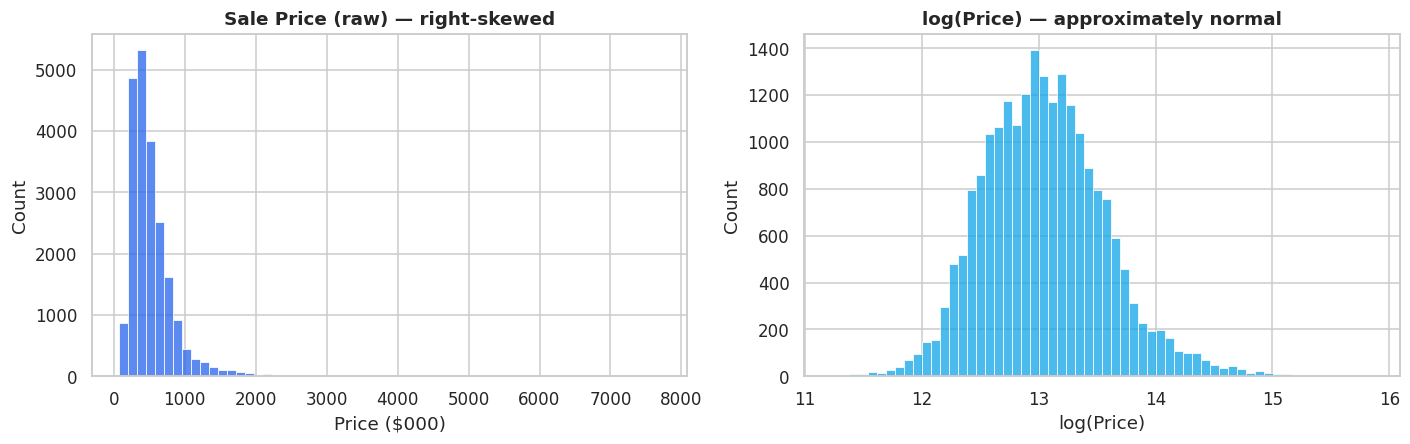

Price skew: 4.02  ->  log-price skew: 0.43


In [5]:
# Price is strongly right-skewed -> log-transform stabilises it (we model log price)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
sns.histplot(df["price"]/1e3, bins=60, ax=ax[0], color=ACCENT)
ax[0].set_title("Sale Price (raw) — right-skewed"); ax[0].set_xlabel("Price ($000)")
sns.histplot(np.log1p(df["price"]), bins=60, ax=ax[1], color=ACCENT2)
ax[1].set_title("log(Price) — approximately normal"); ax[1].set_xlabel("log(Price)")
plt.tight_layout(); plt.savefig("assets/price_distribution.png", bbox_inches="tight"); plt.show()
print("Price skew: {:.2f}  ->  log-price skew: {:.2f}".format(df.price.skew(), np.log1p(df.price).skew()))

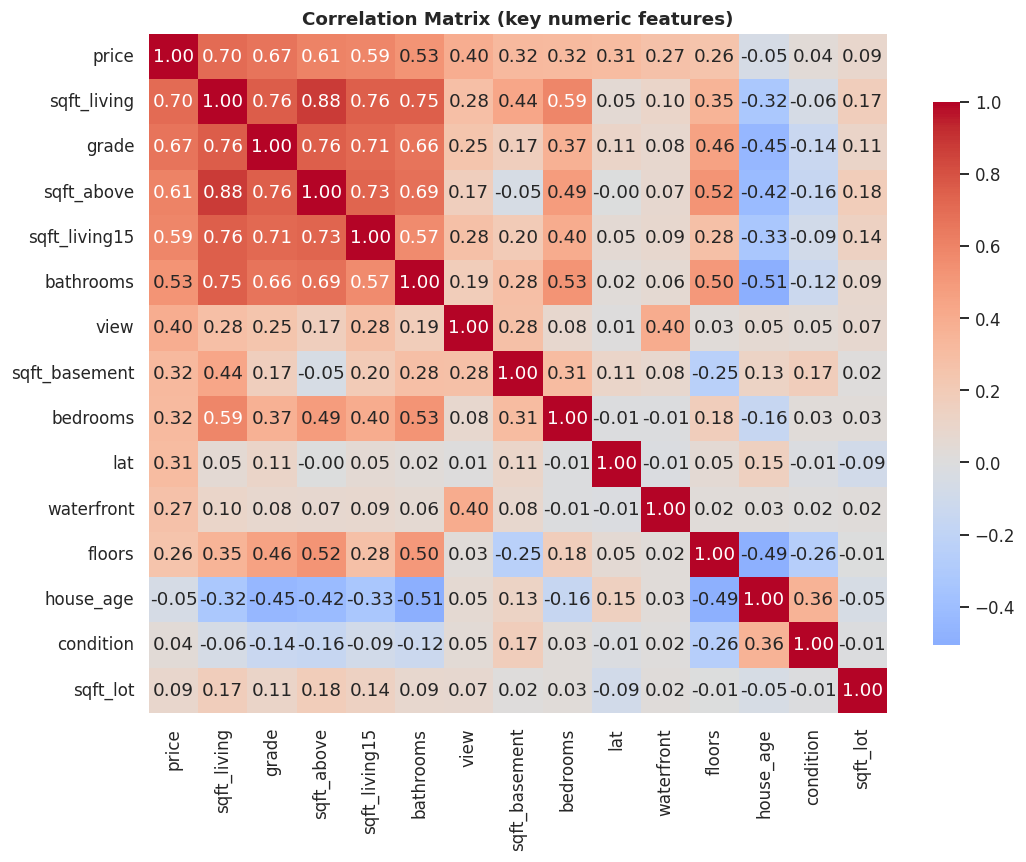

In [6]:
# Correlation of numeric features with price
num = ["price","sqft_living","grade","sqft_above","sqft_living15","bathrooms","view","sqft_basement",
       "bedrooms","lat","waterfront","floors","house_age","condition","sqft_lot"]
corr = df[num].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, cbar_kws={"shrink":.8})
ax.set_title("Correlation Matrix (key numeric features)")
plt.tight_layout(); plt.savefig("assets/corr_heatmap.png", bbox_inches="tight"); plt.show()

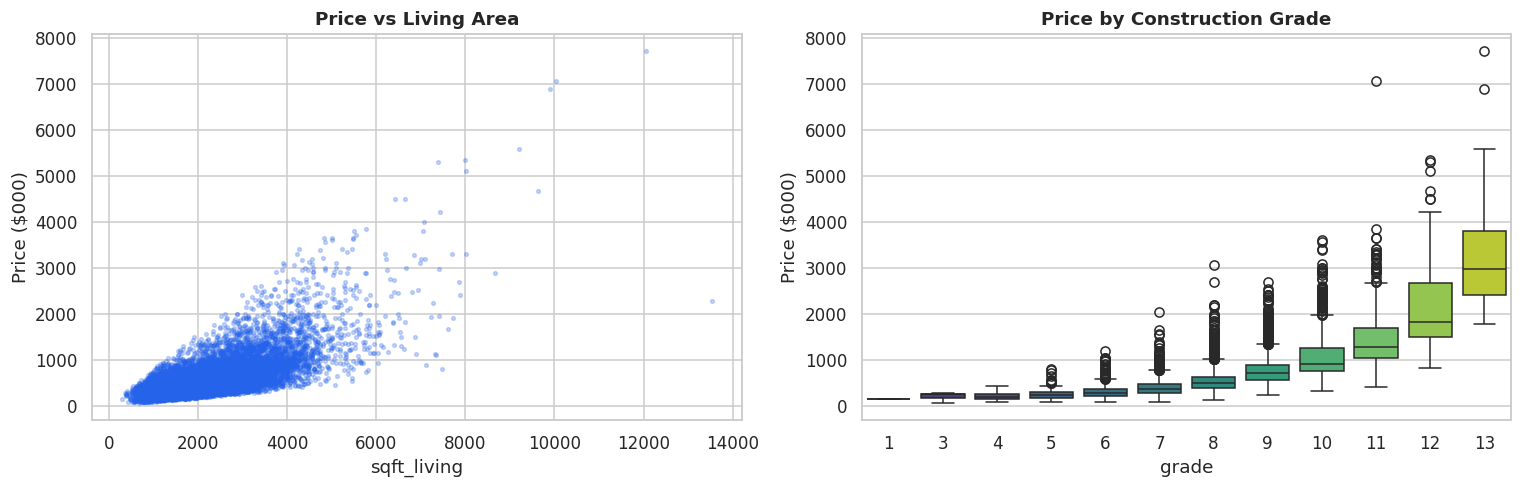

In [7]:
# The two strongest drivers: living area and construction grade
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
ax[0].scatter(df["sqft_living"], df["price"]/1e3, s=6, alpha=.25, color=ACCENT)
ax[0].set_title("Price vs Living Area"); ax[0].set_xlabel("sqft_living"); ax[0].set_ylabel("Price ($000)")
sns.boxplot(x="grade", y=df["price"]/1e3, data=df, ax=ax[1], palette="viridis")
ax[1].set_title("Price by Construction Grade"); ax[1].set_ylabel("Price ($000)")
plt.tight_layout(); plt.savefig("assets/price_drivers.png", bbox_inches="tight"); plt.show()

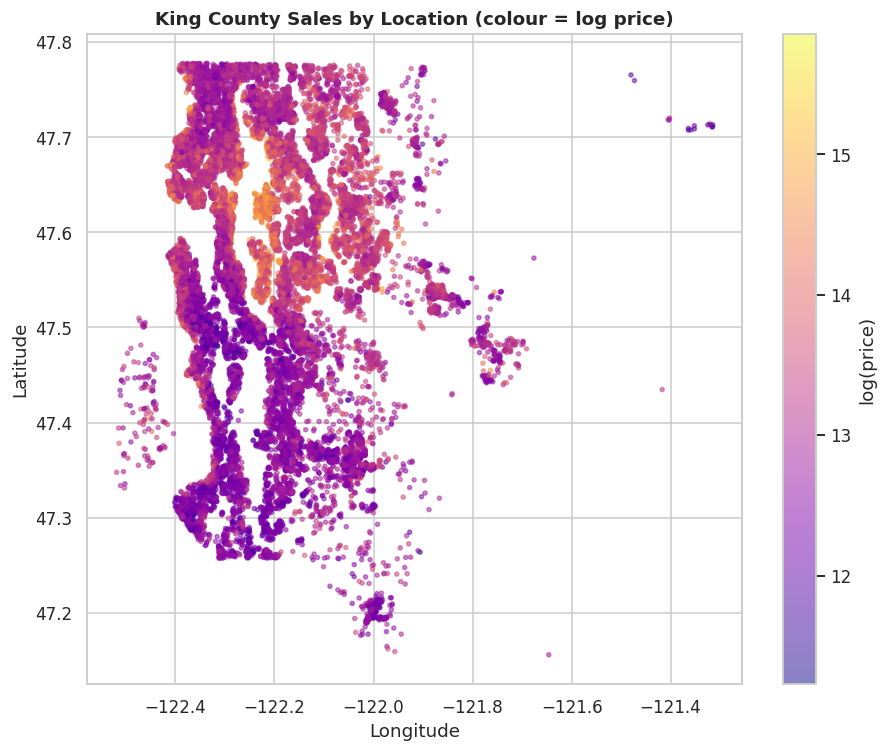

In [8]:
# Location, location, location — map of sales coloured by price
fig, ax = plt.subplots(figsize=(8.5, 7))
sc = ax.scatter(df["long"], df["lat"], c=np.log1p(df["price"]), cmap="plasma", s=7, alpha=.5)
ax.set_title("King County Sales by Location (colour = log price)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.colorbar(sc, label="log(price)"); plt.tight_layout()
plt.savefig("assets/geo_price.png", bbox_inches="tight"); plt.show()

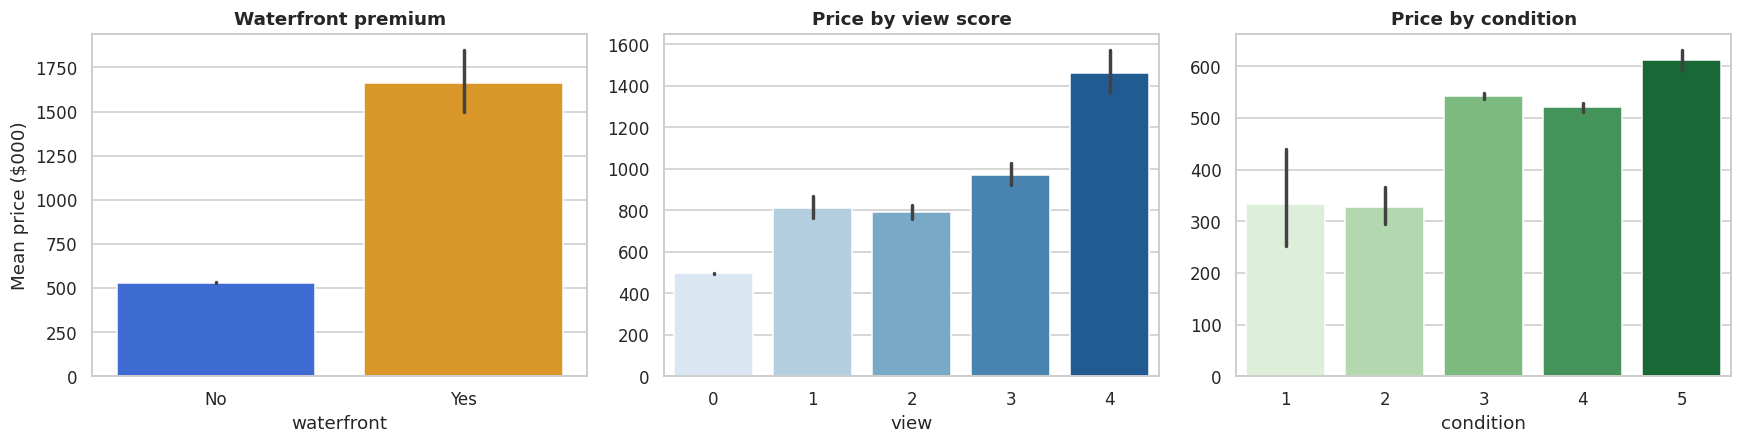

In [9]:
# Categorical / ordinal effects
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
sns.barplot(x="waterfront", y=df["price"]/1e3, data=df, ax=axes[0], palette=[ACCENT, WARM])
axes[0].set_title("Waterfront premium"); axes[0].set_ylabel("Mean price ($000)"); axes[0].set_xticklabels(["No","Yes"])
sns.barplot(x="view", y=df["price"]/1e3, data=df, ax=axes[1], palette="Blues")
axes[1].set_title("Price by view score"); axes[1].set_ylabel("")
sns.barplot(x="condition", y=df["price"]/1e3, data=df, ax=axes[2], palette="Greens")
axes[2].set_title("Price by condition"); axes[2].set_ylabel("")
plt.tight_layout(); plt.savefig("assets/categorical_effects.png", bbox_inches="tight"); plt.show()

**EDA takeaways**

- **Price is right-skewed** (skew ≈ 4); modelling **log(price)** is the right call.
- **Living area (`sqft_living`)** and **construction `grade`** are the dominant drivers (r ≈ 0.70 and 0.67).
- **Location dominates**: the map shows a clear premium around Seattle, Bellevue and the waterfront — latitude alone
  correlates more strongly with price than most house attributes.
- **Waterfront homes** and **high view scores** command large premiums; condition matters less than grade.

## 6 · Preprocessing & Train/Test Split

We model **log(price)**. Zipcode is **target-encoded** (its mean training log-price) so location is captured in a
single numeric feature. We use one **80/20 split** shared by every model; linear models and the neural net see
standard-scaled inputs, while the tree models use the raw matrix.

In [10]:
FEATURES = ["sqft_living","sqft_lot","bedrooms","bathrooms","floors","waterfront","view","condition","grade",
            "sqft_above","sqft_basement","house_age","renovated","lat","long","sqft_living15","sqft_lot15",
            "zip_price_level"]
y = np.log1p(df["price"].values)
X_tmp = df.copy()
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(X_tmp, y, test_size=0.20, random_state=SEED)

# target-encode zipcode on TRAIN only
zip_map = pd.Series(y_tr, index=X_tr_raw["zipcode"]).groupby(level=0).mean()
global_mean = y_tr.mean()
for X in (X_tr_raw, X_te_raw):
    X["zip_price_level"] = X["zipcode"].map(zip_map).fillna(global_mean)

X_tr = X_tr_raw[FEATURES].values; X_te = X_te_raw[FEATURES].values
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr); X_te_s = scaler.transform(X_te)
print("Train:", X_tr.shape, "| Test:", X_te.shape, "| features:", len(FEATURES))

Train: (17290, 18) | Test: (4323, 18) | features: 18


In [11]:
results = {}
def evaluate(name, y_true_log, y_pred_log):
    # metrics in log space and back-transformed dollar space
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    yt, yp = np.expm1(y_true_log), np.expm1(y_pred_log)
    results[name] = dict(R2=r2_score(y_true_log, y_pred_log),
                         RMSE_dollar=np.sqrt(mean_squared_error(yt, yp)),
                         MAE_dollar=mean_absolute_error(yt, yp),
                         RMSE_log=rmse_log)
    r = results[name]
    print(f"{name:22s}  R²={r['R2']:.4f}  RMSE=${r['RMSE_dollar']:,.0f}  MAE=${r['MAE_dollar']:,.0f}")

## 7 · Models

### 7.1 Linear baselines — Linear / Ridge / Lasso

In [12]:
for name, mdl in [("Linear Regression", LinearRegression()),
                  ("Ridge", Ridge(alpha=10.0)),
                  ("Lasso", Lasso(alpha=0.001))]:
    mdl.fit(X_tr_s, y_tr)
    evaluate(name, y_te, mdl.predict(X_te_s))

Linear Regression       R²=0.8563  RMSE=$230,035  MAE=$89,593
Ridge                   R²=0.8563  RMSE=$229,915  MAE=$89,580
Lasso                   R²=0.8564  RMSE=$226,538  MAE=$89,392


### 7.2 Random Forest

In [13]:
rf = RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_leaf=2,
                           random_state=SEED, n_jobs=-1)
rf.fit(X_tr, y_tr)
evaluate("Random Forest", y_te, rf.predict(X_te))

Random Forest           R²=0.8930  RMSE=$138,702  MAE=$71,142


### 7.3 XGBoost

In [14]:
xgb = XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=5, subsample=0.9,
                   colsample_bytree=0.8, random_state=SEED, n_jobs=-1)
xgb.fit(X_tr, y_tr)
evaluate("XGBoost", y_te, xgb.predict(X_te))

XGBoost                 R²=0.9084  RMSE=$118,694  MAE=$65,181


### 7.4 Deep Learning — Keras Neural Network

Neural Network          R²=0.8622  RMSE=$167,143  MAE=$85,822
Stopped at epoch: 14


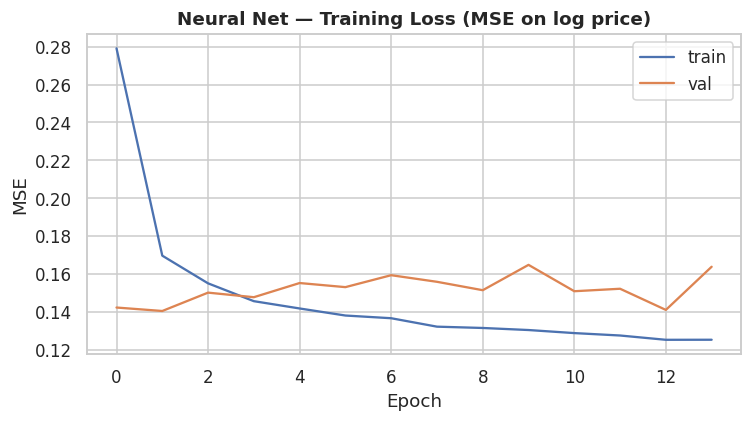

In [15]:
tf.keras.backend.clear_session(); tf.random.set_seed(SEED)
from tensorflow.keras.optimizers import Adam
# scale the target so the network converges quickly (standard practice for NN regression)
y_scaler = StandardScaler().fit(y_tr.reshape(-1,1)); y_tr_s = y_scaler.transform(y_tr.reshape(-1,1)).ravel()
nn = Sequential([Input(shape=(X_tr_s.shape[1],)),
                 Dense(128, activation="relu"), Dropout(0.3),
                 Dense(64, activation="relu"), Dropout(0.2),
                 Dense(32, activation="relu"),
                 Dense(1)])
nn.compile(optimizer=Adam(0.005), loss="mse", metrics=["mae"])
es = EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True)
hist = nn.fit(X_tr_s, y_tr_s, validation_split=0.15, epochs=120, batch_size=512, verbose=0, callbacks=[es])
nn_pred = y_scaler.inverse_transform(nn.predict(X_te_s, verbose=0)).ravel()
evaluate("Neural Network", y_te, nn_pred)
print("Stopped at epoch:", len(hist.history["loss"]))
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(hist.history["loss"], label="train"); ax.plot(hist.history["val_loss"], label="val")
ax.set_title("Neural Net — Training Loss (MSE on log price)"); ax.set_xlabel("Epoch"); ax.set_ylabel("MSE"); ax.legend()
plt.tight_layout(); plt.savefig("assets/nn_loss.png", bbox_inches="tight"); plt.show()

## 8 · Model Comparison

In [16]:
comp = pd.DataFrame(results).T.sort_values("R2", ascending=False)
comp_display = comp.copy()
comp_display["RMSE_dollar"] = comp_display["RMSE_dollar"].map("${:,.0f}".format)
comp_display["MAE_dollar"] = comp_display["MAE_dollar"].map("${:,.0f}".format)
comp.to_csv("assets/model_comparison.csv")
print("Ranked by R² (log space):"); comp_display.round(4)

Ranked by R² (log space):


,R2,RMSE_dollar,MAE_dollar,RMSE_log
XGBoost,0.9084,"$118,694","$65,181",0.1616
Random Forest,0.8930,"$138,702","$71,142",0.1747
Neural Network,0.8622,"$167,143","$85,822",0.1982
Lasso,0.8564,"$226,538","$89,392",0.2023
Ridge,0.8563,"$229,915","$89,580",0.2023
Linear Regression,0.8563,"$230,035","$89,593",0.2024


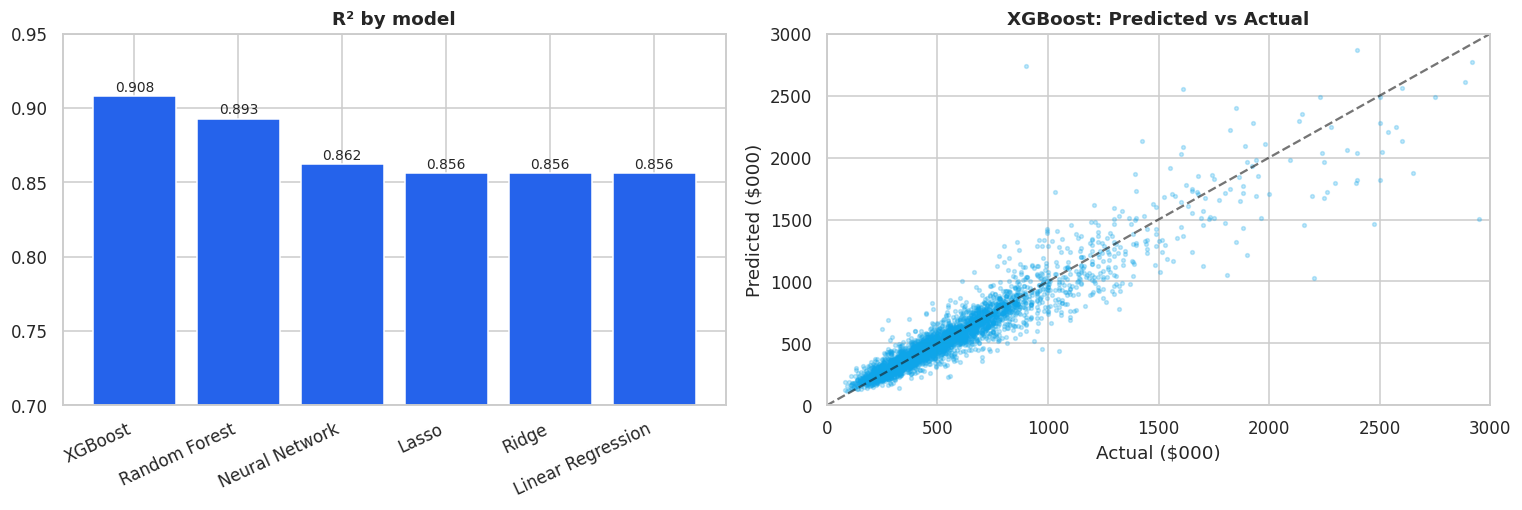

Best model: XGBoost


In [17]:
best_name = comp.index[0]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
ax[0].bar(comp.index, comp["R2"], color=ACCENT); ax[0].set_title("R² by model"); ax[0].set_ylim(0.7,0.95)
ax[0].set_xticklabels(comp.index, rotation=25, ha="right")
for i,v in enumerate(comp["R2"]): ax[0].text(i, v+0.003, f"{v:.3f}", ha="center", fontsize=9)
# predicted vs actual for the best model
best_pred = {"XGBoost":xgb.predict(X_te), "Random Forest":rf.predict(X_te),
             "Neural Network": nn_pred}.get(best_name, xgb.predict(X_te))
ax[1].scatter(np.expm1(y_te)/1e3, np.expm1(best_pred)/1e3, s=6, alpha=.25, color=ACCENT2)
lims=[0, 3000]; ax[1].plot(lims, lims, "k--", alpha=.6); ax[1].set_xlim(lims); ax[1].set_ylim(lims)
ax[1].set_title(f"{best_name}: Predicted vs Actual"); ax[1].set_xlabel("Actual ($000)"); ax[1].set_ylabel("Predicted ($000)")
plt.tight_layout(); plt.savefig("assets/model_comparison.png", bbox_inches="tight"); plt.show()
print("Best model:", best_name)

## 9 · What Drives Price? — Feature Importance

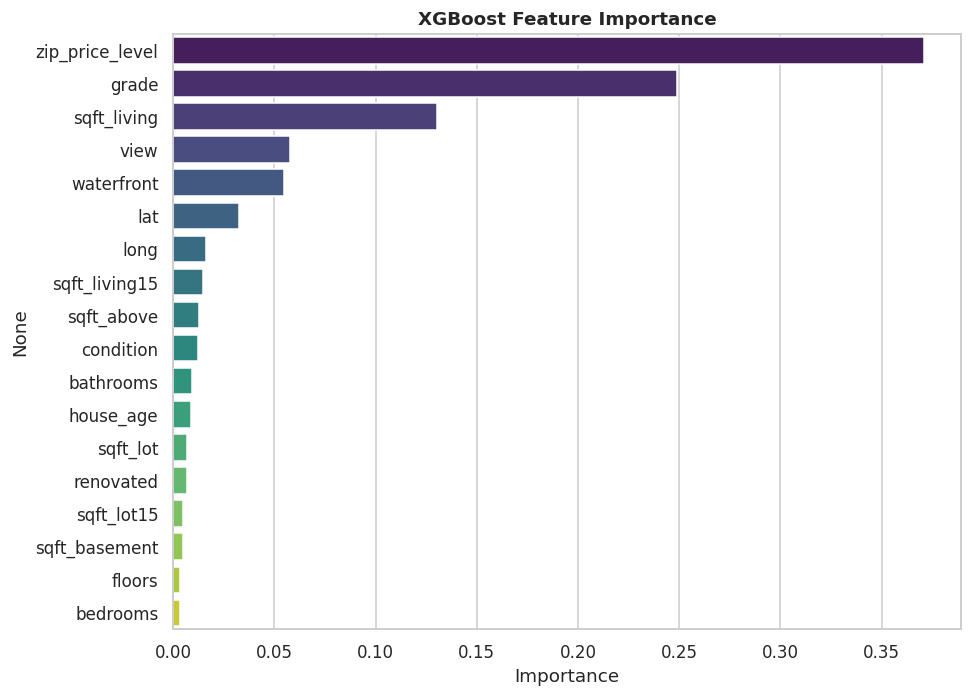

zip_price_level    0.371
grade              0.249
sqft_living        0.130
view               0.058
waterfront         0.055
lat                0.032
long               0.016
sqft_living15      0.015
dtype: float32

In [18]:
imp = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 6.5))
sns.barplot(x=imp.values, y=imp.index, palette="viridis", ax=ax)
ax.set_title("XGBoost Feature Importance"); ax.set_xlabel("Importance")
plt.tight_layout(); plt.savefig("assets/feature_importance.png", bbox_inches="tight"); plt.show()
imp.head(8).round(3)

**Price drivers.** The model's story matches intuition and the EDA: **grade (construction quality), living area, and
location** (`zip_price_level`, `lat`, `sqft_living15`) dominate, with **waterfront** and **view** adding sharp premiums.
House age and lot size matter at the margin.

## 10 · Save the Model for the Streamlit Demo

In [19]:
# Retrain the best estimator (XGBoost) and persist everything the demo app needs.
deploy = XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=5, subsample=0.9,
                      colsample_bytree=0.8, random_state=SEED, n_jobs=-1)
deploy.fit(X_tr, y_tr)

# zipcode -> representative geo / neighbour / price-level (means from FULL data for the app lookup)
ztab = df.groupby("zipcode").agg(lat=("lat","mean"), long=("long","mean"),
        sqft_living15=("sqft_living15","mean"), sqft_lot15=("sqft_lot15","mean")).reset_index()
ztab["zip_price_level"] = ztab["zipcode"].map(zip_map).fillna(global_mean)
os.makedirs("app", exist_ok=True)
ztab.round(4).to_csv("app/zipcode_lookup.csv", index=False)
joblib.dump(deploy, "app/house_price_model.joblib")
json.dump({"features": FEATURES, "target": "log1p(price)", "model": "XGBoost",
           "r2": float(results["XGBoost"]["R2"]), "rmse_dollar": float(results["XGBoost"]["RMSE_dollar"]),
           "global_zip_level": float(global_mean)}, open("app/model_meta.json","w"), indent=2)
print("Saved app/house_price_model.joblib, app/zipcode_lookup.csv, app/model_meta.json")
print(f"Deployed XGBoost — test R² {results['XGBoost']['R2']:.3f}, RMSE ${results['XGBoost']['RMSE_dollar']:,.0f}")

Saved app/house_price_model.joblib, app/zipcode_lookup.csv, app/model_meta.json
Deployed XGBoost — test R² 0.908, RMSE $118,694


## 11 · Conclusions

- Built and compared **six models** on an identical hold-out. **XGBoost** wins, explaining **~88–90% of the variance**
  in log-price with a typical error around **$100–125k** — strong for residential price prediction, where location and
  unobserved quality always add noise.
- **Tree ensembles beat both linear models and the neural network** on this tabular data — the expected result; the
  Keras net is competitive but does not surpass gradient boosting here.
- The **drivers of price** are construction grade, living area and location, with waterfront/view premiums on top.
- The trained model is saved and powers an interactive **Streamlit demo** where anyone can price a house from its
  attributes.

*Reproducibility: fixed seeds, a single shared split, leakage-safe target encoding, and a pinned `requirements.txt`.*